In [2]:
import sys
from pathlib import Path

def add_repo_root_to_path(marker: str = "src") -> Path:
    current = Path.cwd().resolve()

    for candidate in (current, *current.parents):
        if (candidate / marker).is_dir():
            repo_root = candidate
            break
    else:
        raise RuntimeError(f"Could not find a project root containing '{marker}/' from {current}")

    repo_root_str = str(repo_root)
    if repo_root_str not in sys.path:
        sys.path.insert(0, repo_root_str)

    return repo_root

REPO_ROOT = add_repo_root_to_path()
REPO_ROOT

PosixPath('/Users/keaharvan/Documents/University/TinyBIExplore/TinyBI')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from src.config import DATA_PATH

In [4]:
path = f"{DATA_PATH}/minidev_raw/financial/financial.sqlite"
print(path)

conn = sqlite3.connect(path)

/Users/keaharvan/Documents/University/TinyBIExplore/TinyBI/data/minidev_raw/financial/financial.sqlite


In [5]:
TABLES = {
    "account": None,
    "card": None,
    "client": None,
    "disp": None,
    "district": None,
    "loan": None,
    "trans": None,
    "'order'": None,
}

In [6]:
for key, val in TABLES.items():
    if not val:
        TABLES[key] = pd.read_sql_query(f"select * from {key}", conn)

In [7]:
TABLES

{'account':       account_id  district_id         frequency        date
 0              1           18  POPLATEK MESICNE  1995-03-24
 1              2            1  POPLATEK MESICNE  1993-02-26
 2              3            5  POPLATEK MESICNE  1997-07-07
 3              4           12  POPLATEK MESICNE  1996-02-21
 4              5           15  POPLATEK MESICNE  1997-05-30
 ...          ...          ...               ...         ...
 4495       11333            8  POPLATEK MESICNE  1994-05-26
 4496       11349            1    POPLATEK TYDNE  1995-05-26
 4497       11359           61  POPLATEK MESICNE  1994-10-01
 4498       11362           67  POPLATEK MESICNE  1995-10-14
 4499       11382           74  POPLATEK MESICNE  1995-08-20
 
 [4500 rows x 4 columns],
 'card':      card_id  disp_id     type      issued
 0          1        9     gold  1998-10-16
 1          2       19  classic  1998-03-13
 2          3       41     gold  1995-09-03
 3          4       42  classic  1998-11-26
 

In [8]:
for key, val in TABLES.items():
    print(key)
    print(val.describe())
    print("\n")

account
         account_id  district_id
count   4500.000000  4500.000000
mean    2786.067556    37.310444
std     2313.811984    25.177217
min        1.000000     1.000000
25%     1182.750000    13.000000
50%     2368.000000    38.000000
75%     3552.250000    60.000000
max    11382.000000    77.000000


card
           card_id       disp_id
count   892.000000    892.000000
mean    480.855381   3511.862108
std     306.933982   2984.373626
min       1.000000      9.000000
25%     229.750000   1387.000000
50%     456.500000   2938.500000
75%     684.250000   4459.500000
max    1247.000000  13660.000000


client
          client_id  district_id
count   5369.000000  5369.000000
mean    3359.011920    37.310114
std     2832.911984    25.043690
min        1.000000     1.000000
25%     1418.000000    14.000000
50%     2839.000000    38.000000
75%     4257.000000    60.000000
max    13998.000000    77.000000


disp
            disp_id     client_id    account_id
count   5369.000000   5369.000

In [9]:
for key, val in TABLES.items():
    print(key)
    print(val.info())
    print("\n")

account
<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   account_id   4500 non-null   int64
 1   district_id  4500 non-null   int64
 2   frequency    4500 non-null   str  
 3   date         4500 non-null   str  
dtypes: int64(2), str(2)
memory usage: 140.8 KB
None


card
<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   card_id  892 non-null    int64
 1   disp_id  892 non-null    int64
 2   type     892 non-null    str  
 3   issued   892 non-null    str  
dtypes: int64(2), str(2)
memory usage: 28.0 KB
None


client
<class 'pandas.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   client_id    5369 non-null   int64
 1   gender 

In [10]:
for key, val in TABLES.items():
    print(key)
    print(val.head(1))
    print("\n")

account
   account_id  district_id         frequency        date
0           1           18  POPLATEK MESICNE  1995-03-24


card
   card_id  disp_id  type      issued
0        1        9  gold  1998-10-16


client
   client_id gender  birth_date  district_id
0          1      F  1970-12-13           18


disp
   disp_id  client_id  account_id   type
0        1          1           1  OWNER


district
   district_id           A2      A3       A4 A5 A6 A7  A8  A9    A10    A11  \
0            1  Hl.m. Praha  Prague  1204953  0  0  0   1   1  100.0  12541   

   A12   A13  A14      A15    A16  
0  0.2  0.43  167  85677.0  99107  


loan
   loan_id  account_id        date  amount  duration  payments status
0     4959           2  1994-01-05   80952        24    3373.0      A


trans
   trans_id  account_id        date    type operation  amount  balance  \
0         1           1  1995-03-24  PRIJEM     VKLAD    1000     1000   

  k_symbol bank  account  
0      NaN  NaN      NaN  


'orde

Lots of missing transactional data, impute to "Unknown"

<Axes: xlabel='frequency', ylabel='count'>

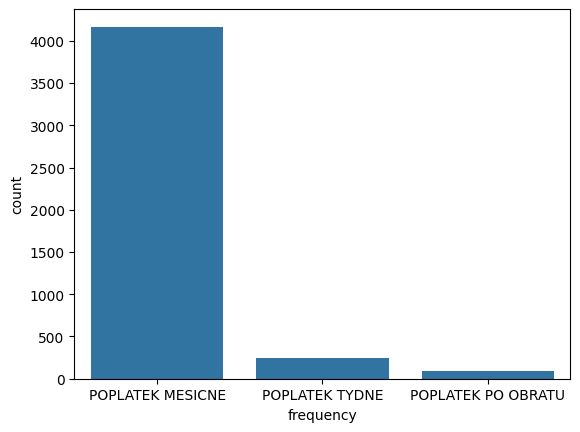

In [11]:
sns.countplot(x=TABLES["account"]["frequency"])

<Axes: xlabel='type', ylabel='count'>

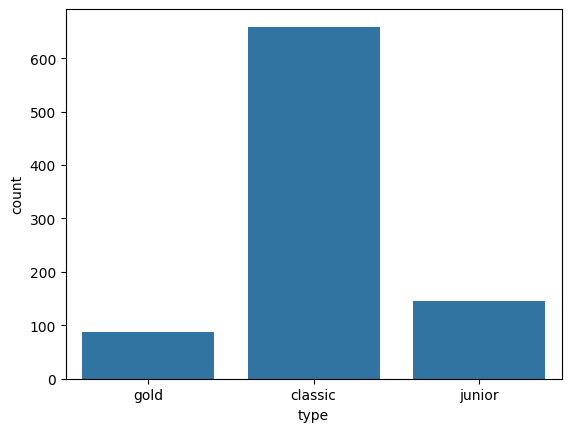

In [12]:
sns.countplot(x=TABLES["card"]["type"])

<Axes: xlabel='gender', ylabel='count'>

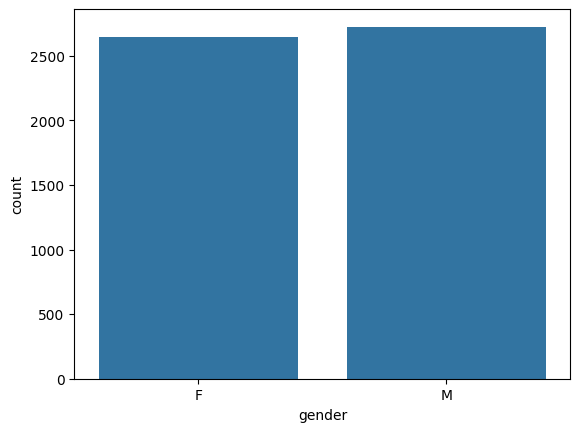

In [13]:
sns.countplot(x=TABLES["client"]["gender"])

<Axes: xlabel='type', ylabel='count'>

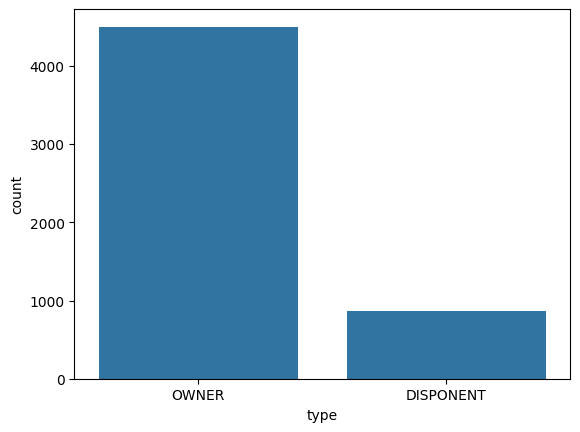

In [14]:
sns.countplot(x=TABLES["disp"]["type"])

In [15]:
TABLES["district"]["A2"].unique()

<StringArray>
[        'Hl.m. Praha',             'Benesov',              'Beroun',
              'Kladno',               'Kolin',          'Kutna Hora',
              'Melnik',      'Mlada Boleslav',             'Nymburk',
      'Praha - vychod',       'Praha - zapad',             'Pribram',
            'Rakovnik',    'Ceske Budejovice',       'Cesky Krumlov',
   'Jindrichuv Hradec',           'Pelhrimov',               'Pisek',
          'Prachatice',          'Strakonice',               'Tabor',
           'Domazlice',                'Cheb',        'Karlovy Vary',
             'Klatovy',       'Plzen - mesto',         'Plzen - jih',
       'Plzen - sever',            'Rokycany',             'Sokolov',
              'Tachov',          'Ceska Lipa',               'Decin',
            'Chomutov',   'Jablonec n. Nisou',             'Liberec',
          'Litomerice',               'Louny',                'Most',
             'Teplice',      'Usti nad Labem',      'Havlickuv Brod',
      

In [16]:
TABLES["district"]["A3"].unique()

<StringArray>
[         'Prague', 'central Bohemia',   'south Bohemia',    'west Bohemia',
   'north Bohemia',    'east Bohemia',   'south Moravia',   'north Moravia']
Length: 8, dtype: str

<Axes: xlabel='status', ylabel='count'>

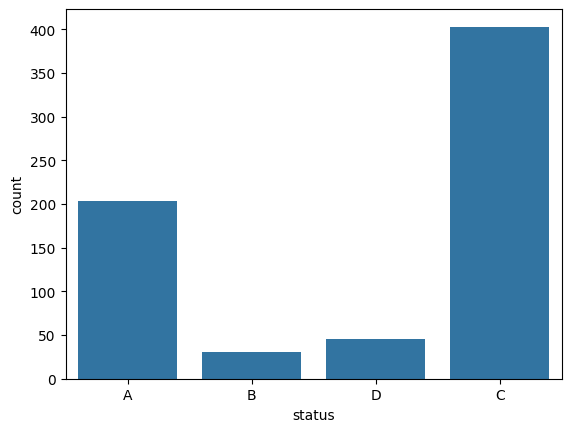

In [17]:
sns.countplot(x=TABLES["loan"]["status"])

<Axes: xlabel='type', ylabel='count'>

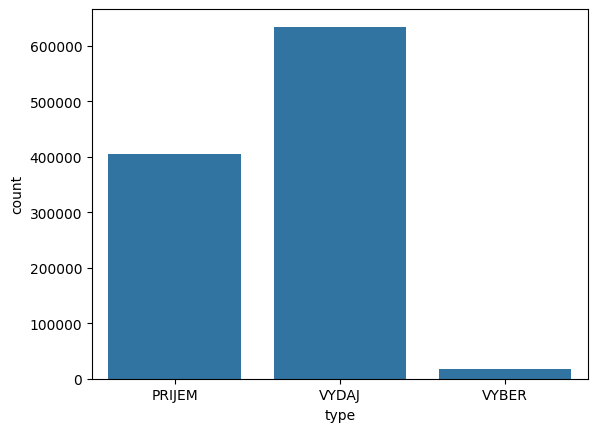

In [18]:
sns.countplot(x=TABLES["trans"]["type"])

In [19]:
# viber shouldn't be a thing when it comes to the trans thing? Keep it for now there are quite a lot, probably missing in schema

<Axes: xlabel='operation', ylabel='count'>

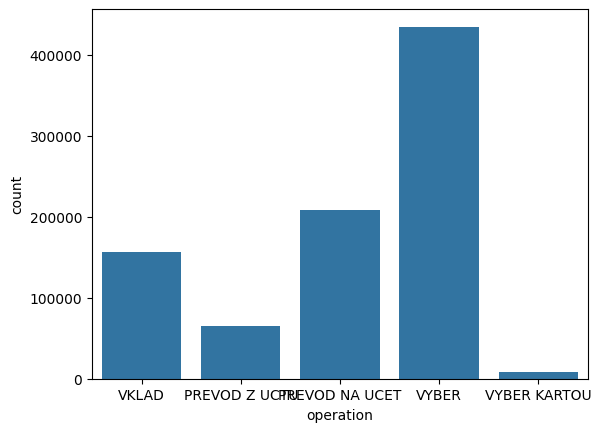

In [20]:
sns.countplot(x=TABLES["trans"]["operation"])

<Axes: xlabel='k_symbol', ylabel='count'>

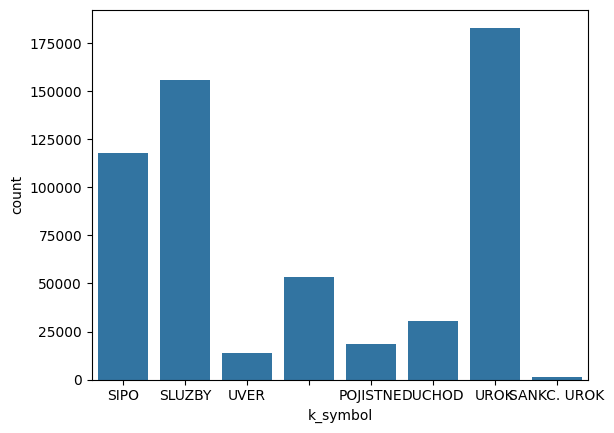

In [21]:
sns.countplot(x=TABLES["trans"]["k_symbol"])

<Axes: xlabel='bank', ylabel='count'>

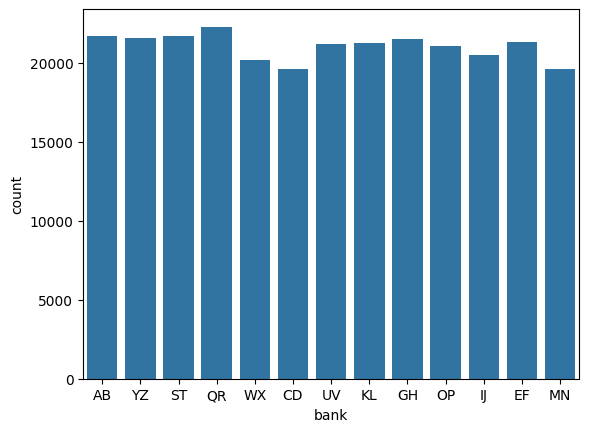

In [22]:
sns.countplot(x=TABLES["trans"]["bank"])

<Axes: xlabel='account', ylabel='Count'>

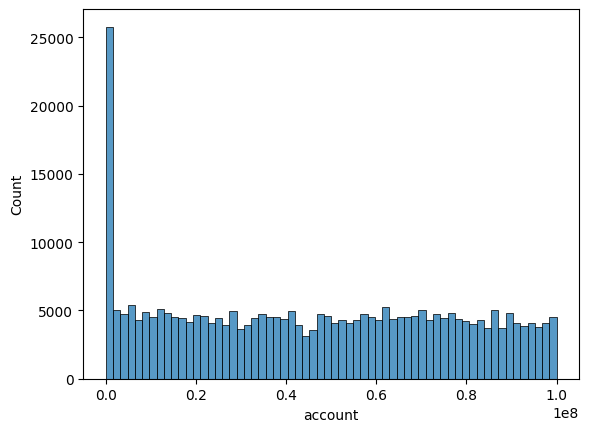

In [23]:
sns.histplot(x=TABLES["trans"]["account"])

In [24]:
len(TABLES["trans"][TABLES["trans"]["account"] == 0])

21881

In [25]:
# I mean not all transactions need another account to deal with

<Axes: xlabel='bank_to', ylabel='count'>

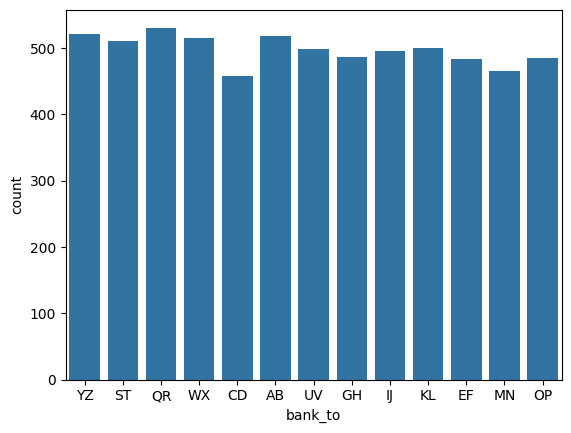

In [26]:
sns.countplot(x=TABLES["'order'"]["bank_to"])

<Axes: xlabel='k_symbol', ylabel='count'>

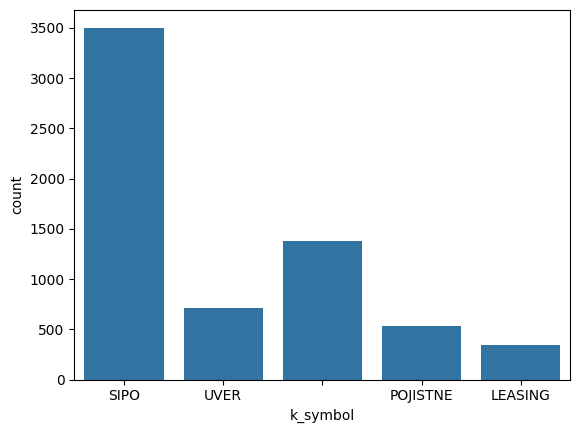

In [27]:
sns.countplot(x=TABLES["'order'"]["k_symbol"])

### Date Ranges

<Axes: xlabel='date'>

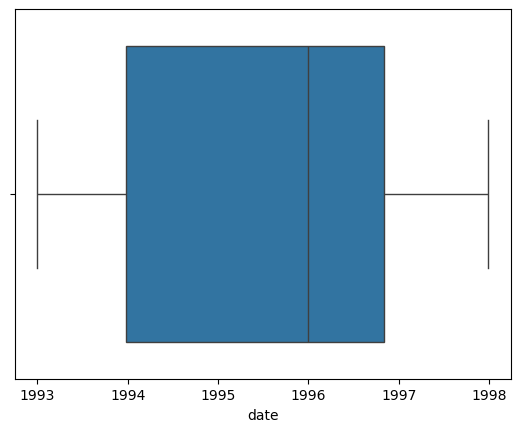

In [28]:
sns.boxplot(x=pd.to_datetime(TABLES["account"]["date"]))

<Axes: xlabel='issued'>

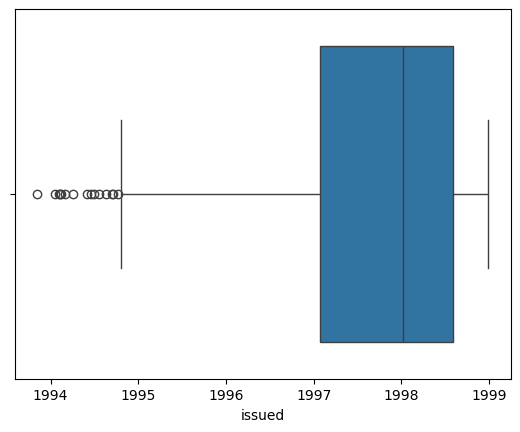

In [29]:
sns.boxplot(x=pd.to_datetime(TABLES["card"]["issued"]))

In [40]:
# get rid of outliers

<Axes: xlabel='birth_date'>

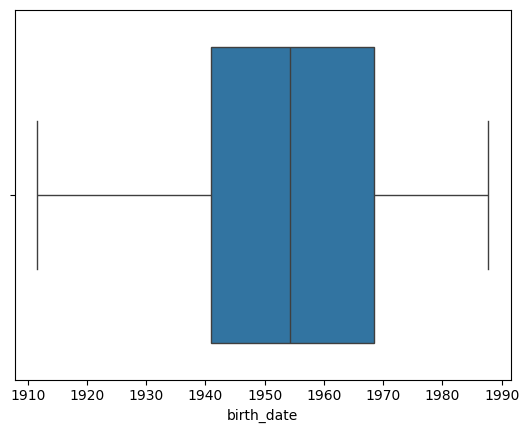

In [30]:
sns.boxplot(x=pd.to_datetime(TABLES["client"]["birth_date"]))

<Axes: xlabel='date'>

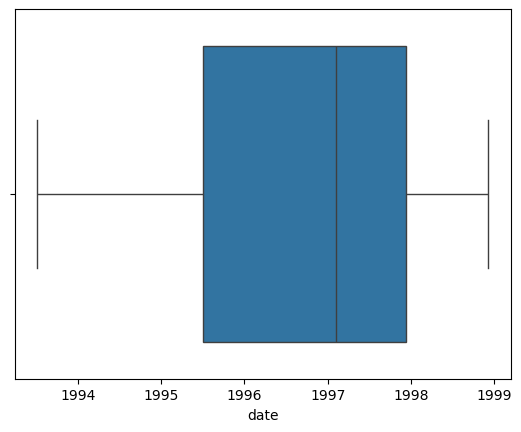

In [31]:
sns.boxplot(x=pd.to_datetime(TABLES["loan"]["date"]))

<Axes: xlabel='date'>

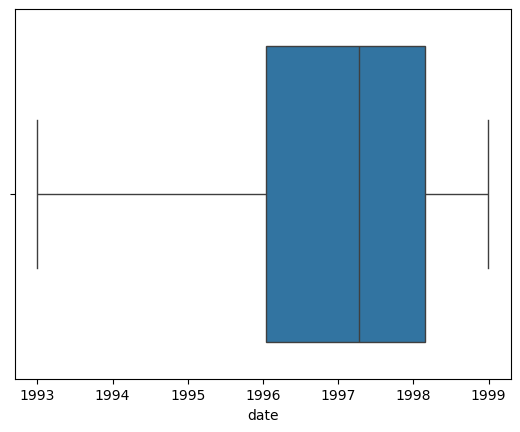

In [32]:
sns.boxplot(x=pd.to_datetime(TABLES["trans"]["date"]))

In [35]:
TABLES["'order'"][TABLES["'order'"]["k_symbol"] == ""].count()

order_id      1379
account_id    1379
bank_to       1379
account_to    1379
amount        1379
k_symbol      1379
dtype: int64

In [39]:
TABLES["trans"][TABLES["trans"]["k_symbol"] == " "].count()

trans_id      53433
account_id    53433
date          53433
type          53433
operation     53433
amount        53433
balance       53433
k_symbol      53433
bank          52817
account       53433
dtype: int64

In [ ]:
# so k symbol has both NaN and " " for trans and "" for order

## Joins

In [47]:
def get_foreign_keys(sqlite_path: str) -> dict:
    conn = sqlite3.connect(sqlite_path)
    
    tables = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table'"
    ).fetchall()
    
    fk_map = {}
    for (table,) in tables:
        fks = conn.execute(
            f"PRAGMA foreign_key_list('{table}')"
        ).fetchall()
        
        if fks:
            fk_map[table] = [
                {
                    "from_col": fk[3],
                    "to_table": fk[2],
                    "to_col": fk[4]
                }
                for fk in fks
            ]
    
    conn.close()
    
    return fk_map

In [48]:
import networkx as nx

def build_and_visualise(fk_map: dict):
    G = nx.DiGraph()
    
    for from_table, fks in fk_map.items():
        G.add_node(from_table)
        for fk in fks:
            G.add_edge(
                from_table,
                fk["to_table"],
                label=f"{fk['from_col']} → {fk['to_col']}"
            )
    
    pos = nx.spring_layout(G, seed=42)
    edge_labels = nx.get_edge_attributes(G, 'label')
    
    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=2000, font_size=10, arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title("Financial Database Schema Graph")
    plt.show()
    
    return G

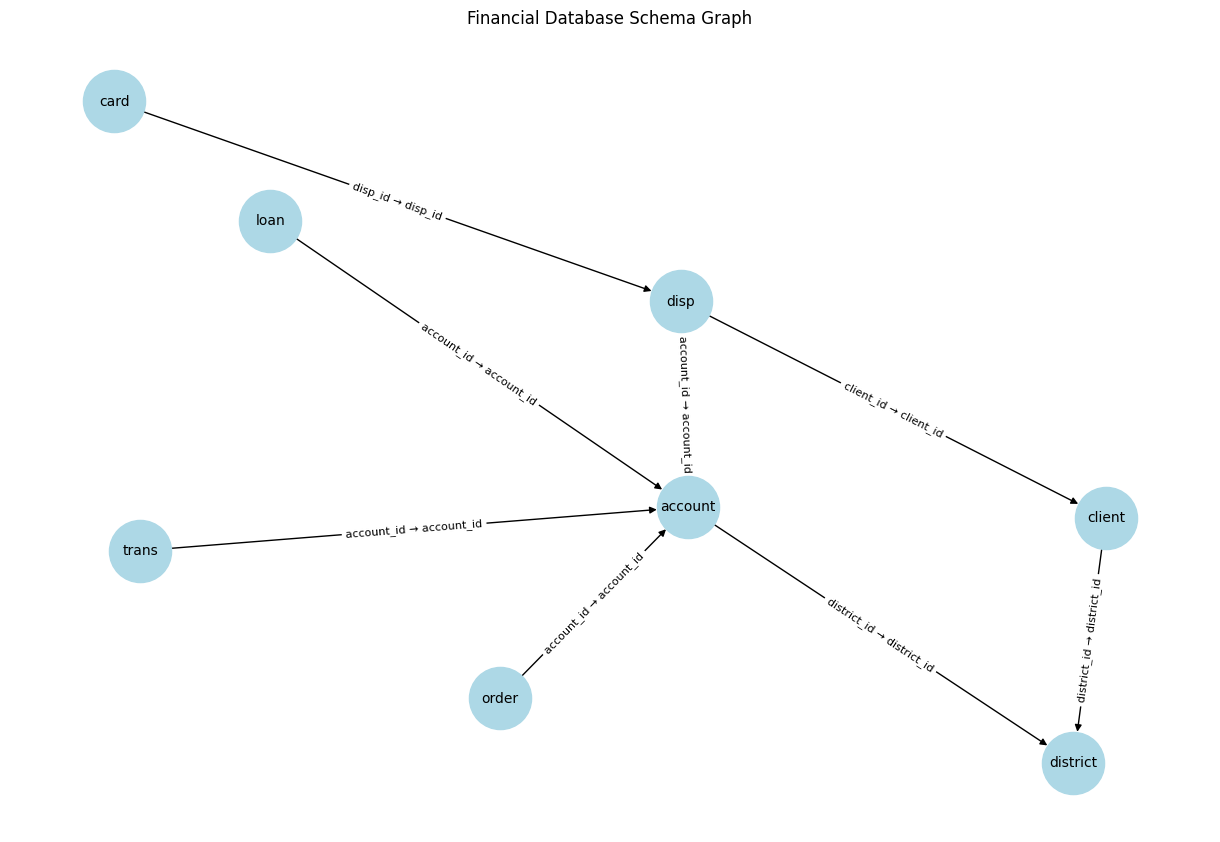

In [49]:
fk_map = get_foreign_keys(path)
network_graph = build_and_visualise(fk_map)

network_graph